In [1]:
#Librerías
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [3]:
def load_spectra_data(h5_path):
    """Carga todos los datos del archivo HDF5"""
    with h5py.File(h5_path, 'r') as f:
        # Cargar el dominio de longitud de onda
        wavelengths = f['wavelength_grid'][:]
        
        # Cargar los valores de redshift y temperatura
        redshifts = f['redshift_values'][:]
        temperatures = f['temperature_values'][:]
        
        # Cargar todos los espectros
        spectra = []
        for i in range(len(redshifts)):
            spec = f[f'spectra/spec_{i}'][:]
            spectra.append(spec)
        
        # Convertir a arrays numpy
        spectra = np.array(spectra)
        
    return wavelengths, spectra, redshifts, temperatures

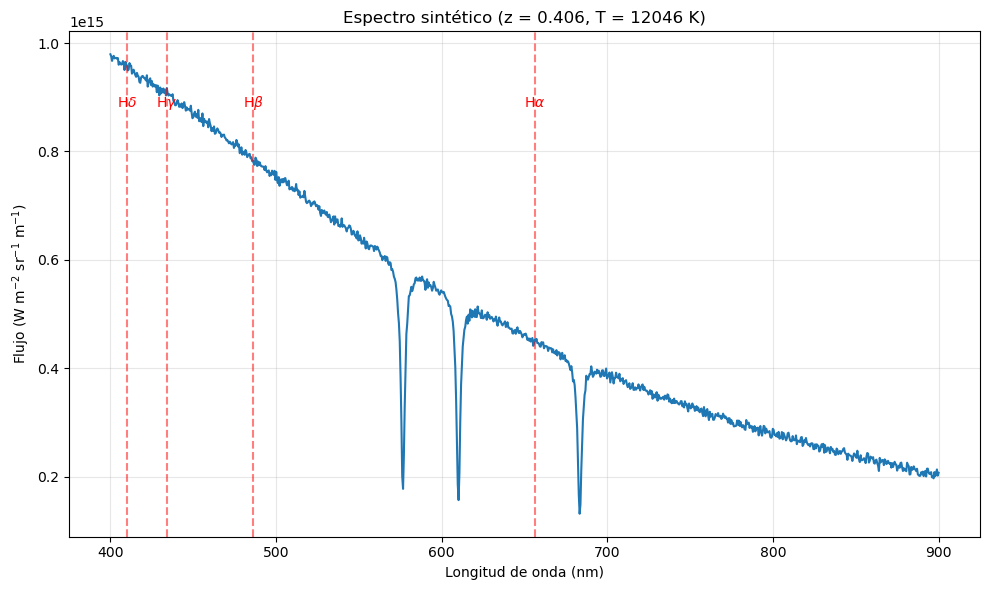

In [5]:
import random

def plot_random_spectrum(h5_path):
    """Selecciona y grafica un espectro aleatorio del archivo HDF5"""
    
    with h5py.File(h5_path, 'r') as f:
        # 1. Determinar cuántos espectros hay
        num_spectra = len(f['redshift_values'])
        
        # 2. Seleccionar un índice aleatorio
        random_idx = random.randint(0, num_spectra - 1)
        
        # 3. Cargar los datos del espectro seleccionado
        wavelength = f['wavelength_grid'][:]
        spectrum = f[f'spectra/spec_{random_idx}'][:]
        z = f['redshift_values'][random_idx]
        T = f['temperature_values'][random_idx]
    
    # 4. Crear la figura
    plt.figure(figsize=(10, 6))
    plt.plot(wavelength * 1e9, spectrum)  # Convertir metros a nanómetros para el gráfico
    
    # 5. Personalizar el gráfico
    plt.title(f'Espectro sintético (z = {z:.3f}, T = {T:.0f} K)')
    plt.xlabel('Longitud de onda (nm)')
    plt.ylabel('Flujo (W m$^{-2}$ sr$^{-1}$ m$^{-1}$)')
    plt.grid(alpha=0.3)
    
    # 6. Marcar las líneas del hidrógeno (opcional)
    H_lines = {
        r'H$\alpha$': 656.28,
        r'H$\beta$': 486.13,
        r'H$\gamma$': 434.05,
        r'H$\delta$': 410.17
    }
    
    for name, line in H_lines.items():
        plt.axvline(x=line, color='red', linestyle='--', alpha=0.5)
        plt.text(line, max(spectrum)*0.9, name, ha='center', color='red')
    
    plt.tight_layout()
    plt.show()

# Uso:
plot_random_spectrum('SpectraData.h5')

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

ModuleNotFoundError: No module named 'torch'